In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
# dataset from https://archive.ics.uci.edu/dataset/360/air+quality
df = pd.read_csv("daten/AirQualityUCI.csv", delimiter=";")

In [3]:
# Date	0 Date
# Time	1 Time
# CO(GT) True hourly averaged concentration CO in mg/m^3  (reference analyzer)
# PT08.S1(CO) PT08.S1 (tin oxide)  hourly averaged sensor response (nominally  CO targeted)
# NMHC(GT) True hourly averaged overall Non Metanic HydroCarbons concentration in microg/m^3 (reference analyzer)
# C6H6(GT) True hourly averaged Benzene concentration  in microg/m^3 (reference analyzer)
# PT08.S2(NMHC) PT08.S2 (titania) hourly averaged sensor response (nominally NMHC targeted)
# NOx(GT) True hourly averaged NOx concentration  in ppb (reference analyzer)
# PT08.S3(NOx) PT08.S3 (tungsten oxide) hourly averaged sensor response (nominally NOx targeted) 
# NO2(GT) True hourly averaged NO2 concentration in microg/m^3 (reference analyzer)
# PT08.S4(NO2) PT08.S4 (tungsten oxide) hourly averaged sensor response (nominally NO2 targeted)
# PT08.S5(O3) PT08.S5 (indium oxide) hourly averaged sensor response (nominally O3 targeted)
# T Temperature in °C
# RH Relative Humidity (%) 
# AH Absolute Humidity

In [4]:
# rename columns for easier handling
df = df.rename(columns={
    'C6H6(GT)': 'benzene',
    'CO(GT)': 'CO',
    'NMHC(GT)': 'NMHC',
    'NOx(GT)': 'NOx',
    'NO2(GT)': 'NO2',
    'PT08.S1(CO)': 's1_CO',
    'PT08.S2(NMHC)': 's2_NMHC',
    'PT08.S3(NOx)': 's3_NOx',
    'PT08.S4(NO2)': 's4_NO2',
    'PT08.S5(O3)': 's5_O3'
})

In [5]:
df.info()
# Einige der Spalten sind vom Typ String. Das sollten wir uns genauer ansehen.
# Die Spalten Unnamed 15 & 16 scheinen auch unnütz

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         9357 non-null   str    
 1   Time         9357 non-null   str    
 2   CO           9357 non-null   str    
 3   s1_CO        9357 non-null   float64
 4   NMHC         9357 non-null   float64
 5   benzene      9357 non-null   str    
 6   s2_NMHC      9357 non-null   float64
 7   NOx          9357 non-null   float64
 8   s3_NOx       9357 non-null   float64
 9   NO2          9357 non-null   float64
 10  s4_NO2       9357 non-null   float64
 11  s5_O3        9357 non-null   float64
 12  T            9357 non-null   str    
 13  RH           9357 non-null   str    
 14  AH           9357 non-null   str    
 15  Unnamed: 15  0 non-null      float64
 16  Unnamed: 16  0 non-null      float64
dtypes: float64(10), str(7)
memory usage: 1.6 MB


In [6]:
df.head()
# In Unnamed steht nichts drin
# Die String-Spalten haben Komma ',' statt Punkt '.' für die Zahlen

,Date,Time,CO,s1_CO,NMHC,benzene,s2_NMHC,NOx,s3_NOx,NO2,s4_NO2,s5_O3,T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [7]:
df.isna().sum()
# Offensichtlich fehlen auch 114 Werte, wahrscheinlich alle die selben.

Date            114
Time            114
CO              114
s1_CO           114
NMHC            114
benzene         114
s2_NMHC         114
NOx             114
s3_NOx          114
NO2             114
s4_NO2          114
s5_O3           114
T               114
RH              114
AH              114
Unnamed: 15    9471
Unnamed: 16    9471
dtype: int64

In [8]:
df.shape

(9471, 17)

<Axes: >

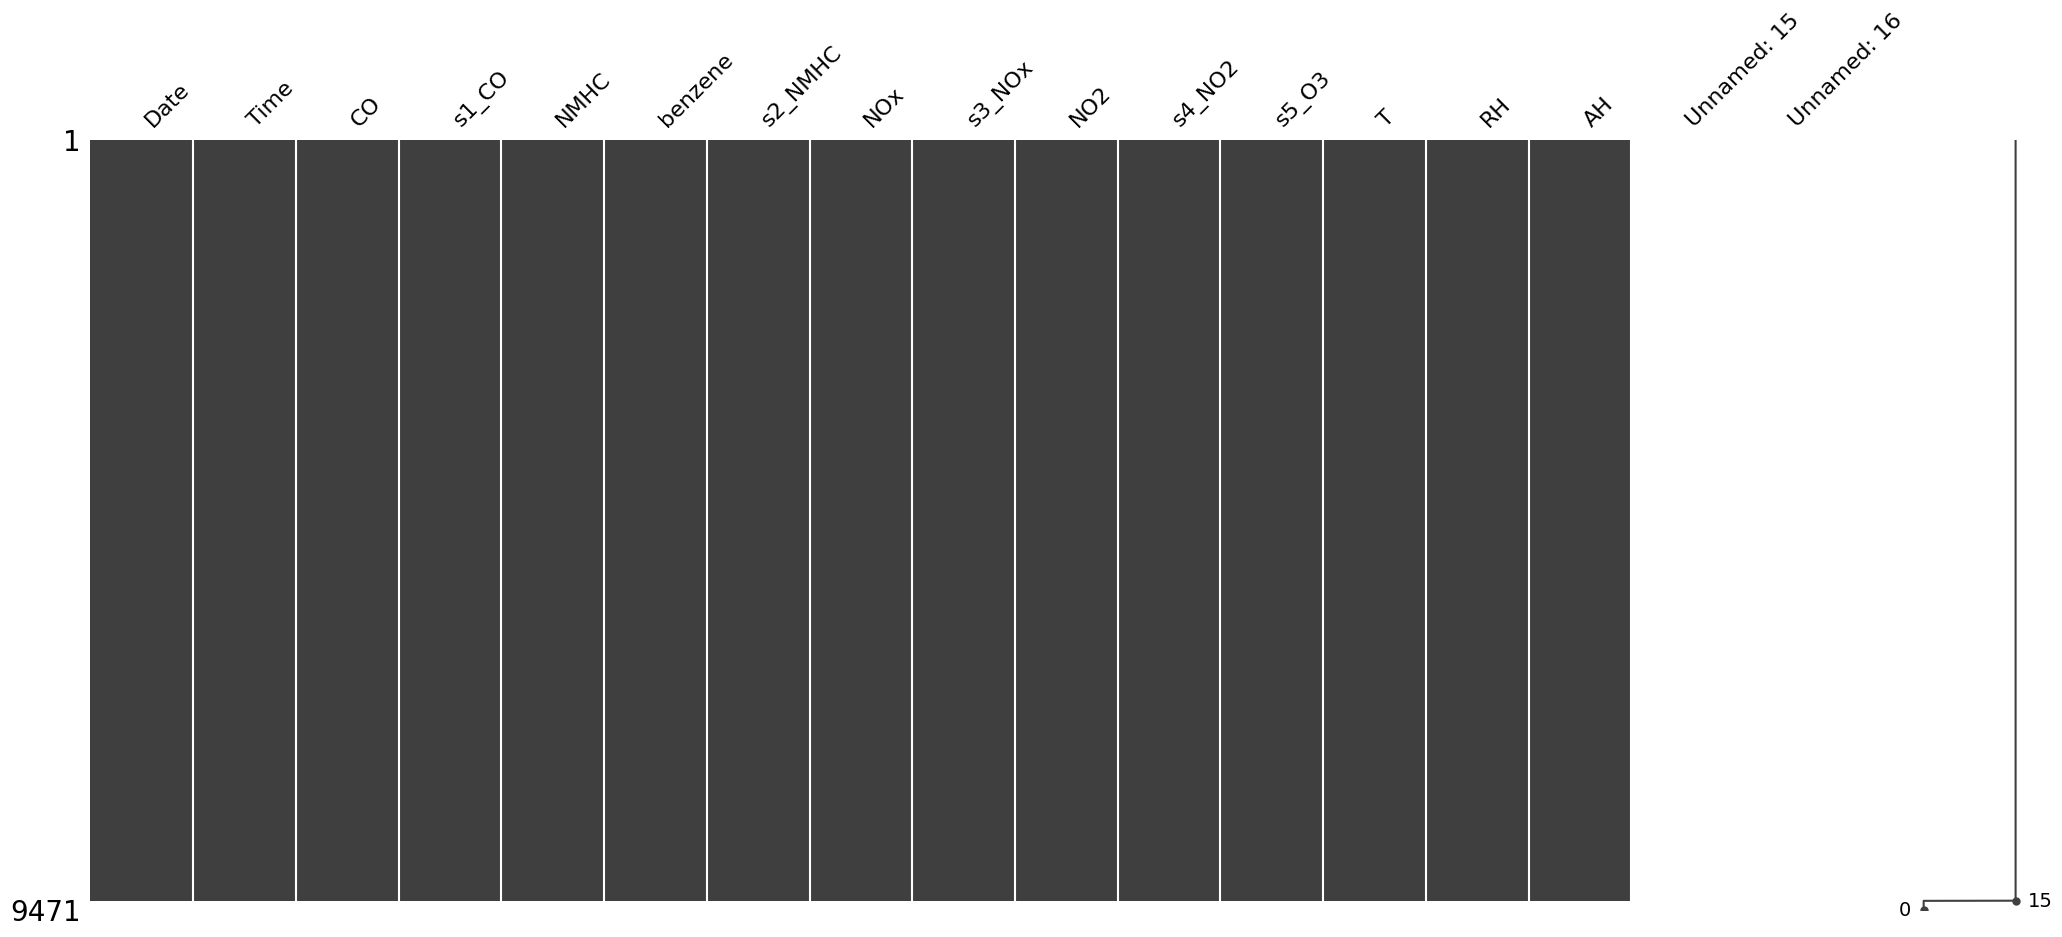

In [9]:
import missingno as mno

mno.matrix(df) # Auflösung zu klein

<Axes: >

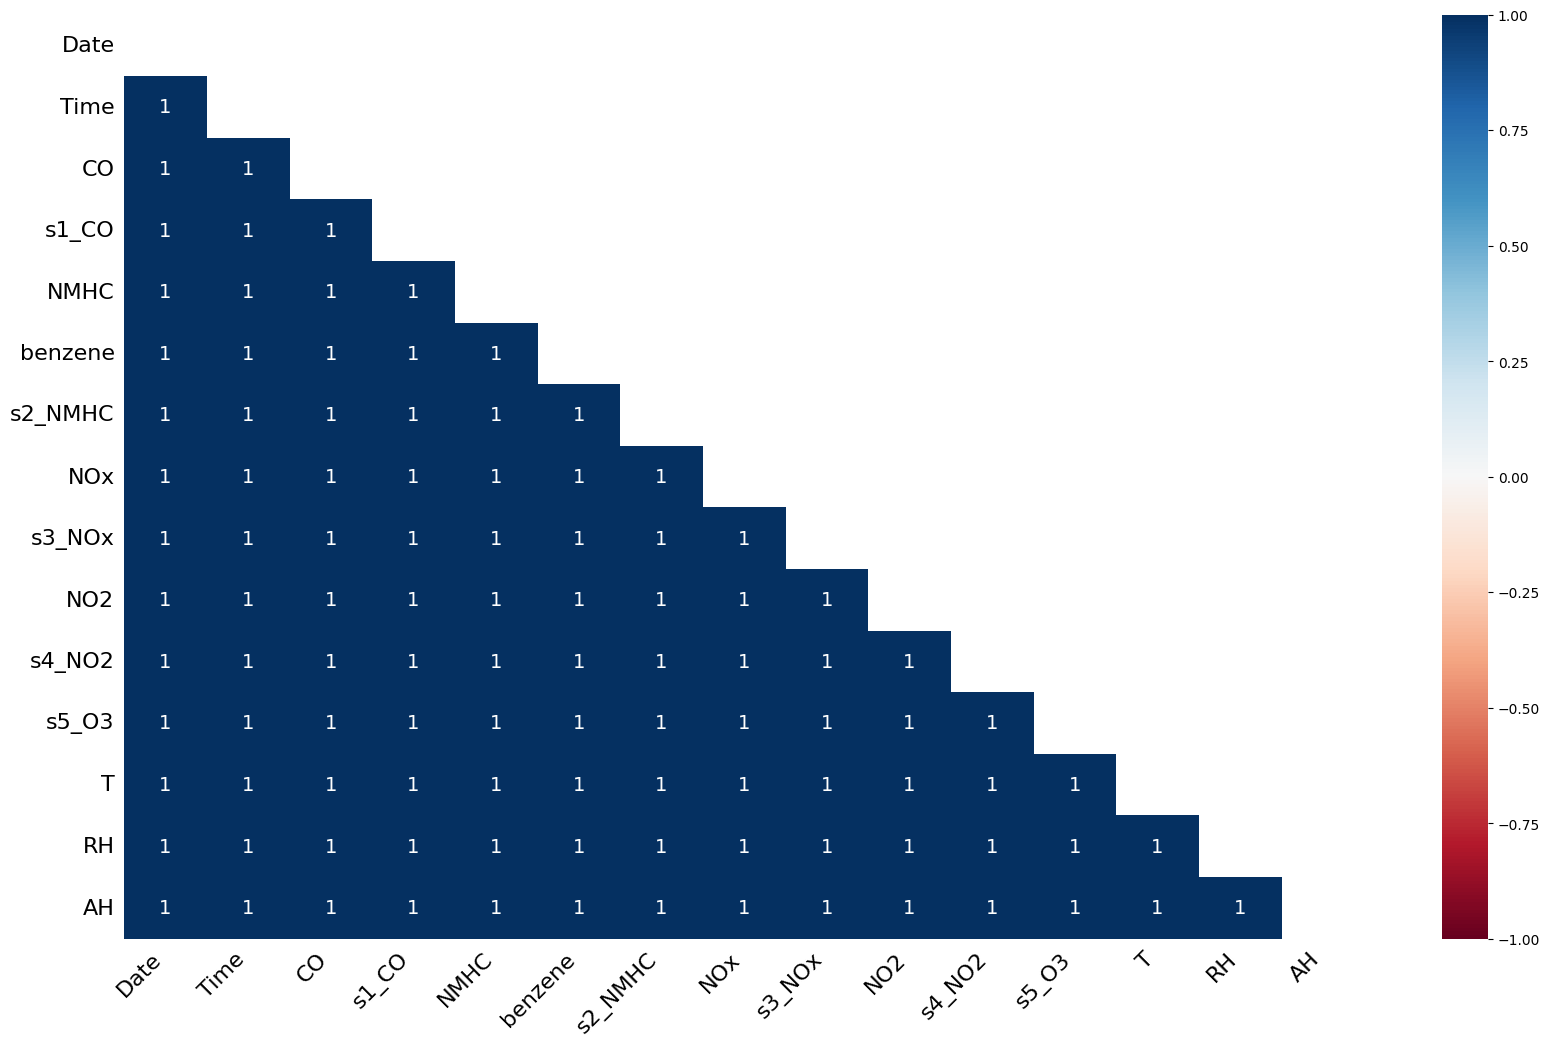

In [10]:
mno.heatmap(df)
# Korrelation==1: es fehlen wohl wirklich die Zeilen vollständig

In [11]:
# Kontrolle
df[df["T"].isna()]

,Date,Time,CO,s1_CO,NMHC,benzene,s2_NMHC,NOx,s3_NOx,NO2,s4_NO2,s5_O3,T,RH,AH,Unnamed: 15,Unnamed: 16
9357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Entferne überschüssige Spalten
df = df.drop("Unnamed: 15", axis=1)
df = df.drop("Unnamed: 16", axis=1)

In [13]:
# Die 114 NA-Zeilen entfernen -- dropna() passt hier gut
df = df.dropna()

In [14]:
df.shape

(9357, 15)

In [15]:
# CO, benzene, T, RH, AH : sind Strings, sollten float sein -> Komma durch Punkt ersetzen
for col in ["CO", "benzene", "T", "RH", "AH"]:
    df[col] = df[col].str.replace(",", ".").astype(np.float64)

In [16]:
# Date und Time in wirklichen Timestamp
df["timestamp"] = pd.to_datetime(
    df["Date"] + ":" + df["Time"],
    format="%d/%m/%Y:%H.%M.%S"
)
df = df.drop("Date", axis=1).drop("Time", axis=1)

In [17]:
# missing values sind als -200 kodiert
for col in df.columns:
    df[col] = df[col].replace(-200, np.nan)

Damit ist die erste auf Aufräumaktion erledigt. 

Wir haben auch keine echten Annahmen getroffen -- nur offensichtliche Transformationen/Kodierungen durchgeführt.

In [18]:
df.isna().sum()
# 366 sieht wieder verdächtig danach aus, dass die Werte in allen Reihen fehlen

CO           1683
s1_CO         366
NMHC         8443
benzene       366
s2_NMHC       366
NOx          1639
s3_NOx        366
NO2          1642
s4_NO2        366
s5_O3         366
T             366
RH            366
AH            366
timestamp       0
dtype: int64

<Axes: >

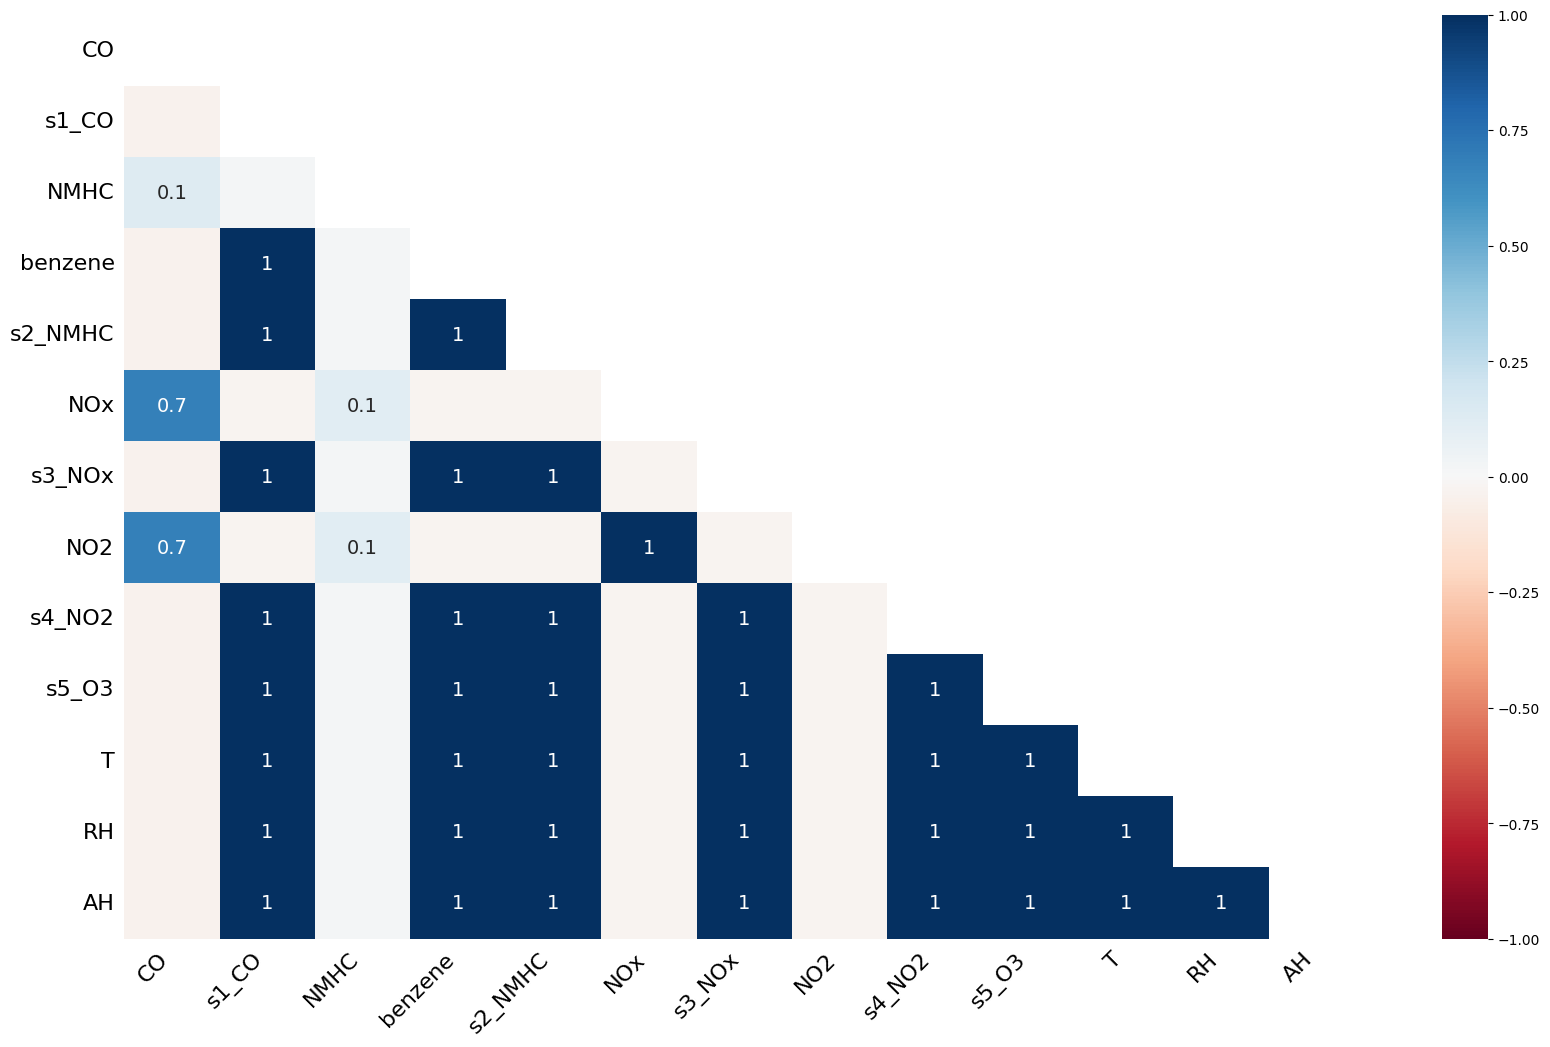

In [19]:
mno.heatmap(df)
# Heatmap bestätigt unsere Annahme

In [20]:
# Kontrolle
df[df["benzene"].isna()]

,CO,s1_CO,NMHC,benzene,s2_NMHC,NOx,s3_NOx,NO2,s4_NO2,s5_O3,T,RH,AH,timestamp
524,1.7,NaN,222.0,NaN,NaN,99.0,NaN,72.0,NaN,NaN,NaN,NaN,NaN,2004-04-01 14:00:00
525,1.9,NaN,197.0,NaN,NaN,108.0,NaN,81.0,NaN,NaN,NaN,NaN,NaN,2004-04-01 15:00:00
526,2.3,NaN,319.0,NaN,NaN,131.0,NaN,93.0,NaN,NaN,NaN,NaN,NaN,2004-04-01 16:00:00
701,2.0,NaN,137.0,NaN,NaN,129.0,NaN,106.0,NaN,NaN,NaN,NaN,NaN,2004-04-08 23:00:00
702,2.4,NaN,189.0,NaN,NaN,154.0,NaN,109.0,NaN,NaN,NaN,NaN,NaN,2004-04-09 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8111,6.6,NaN,NaN,NaN,NaN,1227.0,NaN,326.0,NaN,NaN,NaN,NaN,NaN,2005-02-11 17:00:00
8112,6.5,NaN,NaN,NaN,NaN,1061.0,NaN,284.0,NaN,NaN,NaN,NaN,NaN,2005-02-11 18:00:00
8113,7.1,NaN,NaN,NaN,NaN,1075.0,NaN,289.0,NaN,NaN,NaN,NaN,NaN,2005-02-11 19:00:00
8114,4.9,NaN,NaN,NaN,NaN,641.0,NaN,215.0,NaN,NaN,NaN,NaN,NaN,2005-02-11 20:00:00


In [21]:
# Wir entfernen wieder alle Zeilen, die fast vollständig fehlen
df = df[df["benzene"].notna()]

In [22]:
df.shape

(8991, 14)

In [23]:
# Sieht gut aus
df.isna().sum()

CO           1647
s1_CO           0
NMHC         8104
benzene         0
s2_NMHC         0
NOx          1595
s3_NOx          0
NO2          1598
s4_NO2          0
s5_O3           0
T               0
RH              0
AH              0
timestamp       0
dtype: int64

In [24]:
# Für unsere weitere Untersuchung interessieren wir uns nur für die Werte des Multisensors (sx_...),
# den Benzolwert und den Zeitstempel
air = df[["benzene", "T", "AH", "RH", "s1_CO", "s2_NMHC",
          "s3_NOx", "s4_NO2", "s5_O3", "timestamp"]]

In [25]:
air.describe().round(2)

,benzene,T,AH,RH,s1_CO,s2_NMHC,s3_NOx,s4_NO2,s5_O3,timestamp
count,8991.00,8991.00,8991.00,8991.00,8991.00,8991.00,8991.00,8991.00,8991.00,8991
mean,10.08,18.32,1.03,49.23,1099.83,939.15,835.49,1456.26,1022.91,2004-09-20 04:59:35.175175
min,0.10,-1.90,0.18,9.20,647.00,383.00,322.00,551.00,221.00,2004-03-10 18:00:00
25%,4.40,11.80,0.74,35.80,937.00,734.50,658.00,1227.00,731.50,2004-06-14 02:30:00
50%,8.20,17.80,1.00,49.60,1063.00,909.00,806.00,1463.00,963.00,2004-09-20 04:00:00
75%,14.00,24.40,1.31,62.50,1231.00,1116.00,969.50,1674.00,1273.50,2004-12-26 04:30:00
max,63.70,44.60,2.23,88.70,2040.00,2214.00,2683.00,2775.00,2523.00,2005-04-04 14:00:00
std,7.45,8.83,0.40,17.32,217.08,266.83,256.82,346.21,398.48,NaN


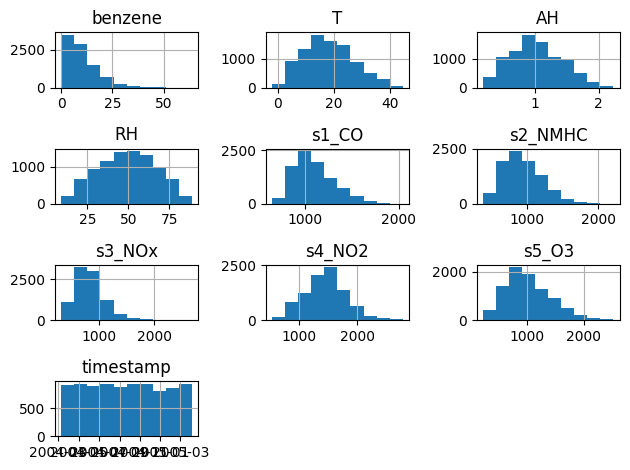

In [26]:
air.hist()
plt.tight_layout()

In [27]:
import fragebogen

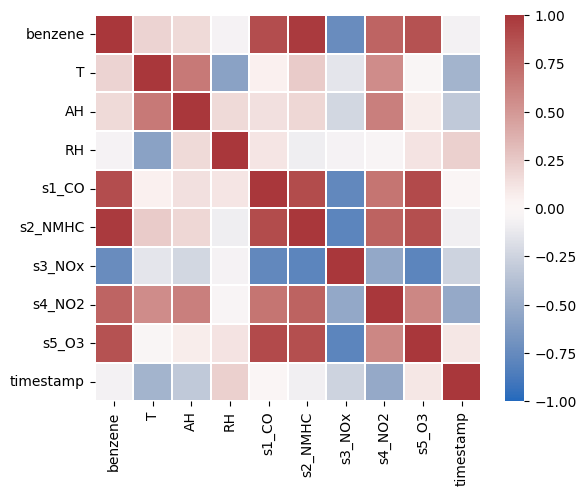

In [28]:
fragebogen.plot_corr(air, annot=False)

In [29]:
import regression

# Modell 1
m1 = regression.fit_ols("benzene ~ T + AH + RH + "
                        "s1_CO + s2_NMHC + s3_NOx + s4_NO2 + s5_O3", data=air)

In [30]:
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                benzene   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                 4.180e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:22:24   Log-Likelihood:                -14433.
No. Observations:                8991   AIC:                         2.888e+04
Df Residuals:                    8982   BIC:                         2.895e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.5509      0.210   -107.415      0.0

In [31]:
regression.std_beta_effectsize(m1).round(3)

,coef,std_beta,partial_eta2,p_value
s2_NMHC,0.031,1.109,0.745,0.000
s3_NOx,0.005,0.161,0.186,0.000
T,-0.100,-0.119,0.038,0.000
AH,1.771,0.096,0.034,0.000
s1_CO,0.002,0.044,0.009,0.000
RH,-0.018,-0.042,0.009,0.000
s4_NO2,-0.001,-0.029,0.003,0.000
s5_O3,-0.000,-0.010,0.000,0.039


In [32]:
# Wenn die vier schwächsten Variablen entfernt werden, ändert sich am R² so gut wie gar nichts.
m2 = regression.fit_ols("benzene ~ T + AH + s2_NMHC + s3_NOx", data=air)
print(m2.rsquared.round(3))

0.973


In [33]:
# Entfernen wir jedoch die stärkste Variable, passieren unerwartete Dinge.
m3 = regression.fit_ols("benzene ~ T + AH + RH + "
                        "s1_CO + s3_NOx + s4_NO2 + s5_O3", data=air)
# R² sinkt stark ab; das war noch zu erwarten.
print(m3.rsquared.round(3))

0.897


In [34]:
# Aber hier ist alles durcheinander gewürfelt.
regression.std_beta_effectsize(m3).round(3)

,coef,std_beta,partial_eta2,p_value
s4_NO2,0.012,0.543,0.325,0.0
s5_O3,0.006,0.318,0.126,0.0
s1_CO,0.007,0.192,0.044,0.0
RH,-0.068,-0.157,0.031,0.0
AH,-2.596,-0.141,0.021,0.0
T,-0.101,-0.120,0.010,0.0
s3_NOx,-0.003,-0.101,0.028,0.0


Warum sehen wir eine so große Änderung bei der Effektgröße? Warum drehen sich Vorzeichen der Koeffizienten um (z.B. AH)?

Der wahrscheinlichste Grund ist **starke gemeinsame Varianz / Multikollinearität zwischen den Luftschadstoff-Sensorvariablen**. `s2_NMHC` scheint im ursprünglichen Modell sehr viel der erklärbaren Varianz zu tragen. Wenn diese Variable entfernt wird, müssen andere Variablen jene Information übernehmen, die vorher durch `s2_NMHC` gebunden war.

Wichtig: Ein Regressionskoeffizient ist **kein isolierter Zusammenhang**, sondern ein **partieller Effekt**:

> Effekt von Variable X auf Y, **wenn alle anderen Variablen konstant gehalten werden**.

Wenn man eine zentrale Variable entfernt, ändert sich daher die Bedeutung von "*alle anderen konstant gehalten*".

Im Beispiel:

| Variable | std_beta vorher | std_beta nachher | Veränderung |
|---:|---:|---:|---|
| `s2_NMHC` | 1.109 | – | Variable entfernt |
| `s4_NO2` | -0.029 | 0.543 | anderes Vorzeichen, deutlich größer |
| `s5_O3` | -0.010 | 0.318 | anderes Vorzeichen, deutlich größer |
| `s3_NOx` | 0.161 | -0.101 | anderes Vorzeichen |
| `AH` | 0.096 | -0.141 | anderes Vorzeichen |

Das ist ein klassisches Zeichen dafür, dass `s2_NMHC` mit mehreren anderen Prädiktoren stark zusammenhängt. Solange `s2_NMHC` im Modell ist, misst z. B. `s4_NO2` nur noch den Teil von `s4_NO2`, der **nicht bereits durch `s2_NMHC` erklärt wird**. Dieser Rest kann klein sein oder sogar eine andere Richtung haben.

Wenn `s2_NMHC` entfernt wird, wird `s4_NO2` plötzlich zu einem **Ersatzindikator** für einen Teil der Information, die vorher `s2_NMHC` getragen hat. Dadurch kann sein Koeffizient stark wachsen und sogar das Vorzeichen wechseln.

### Warum kann sich das Vorzeichen umkehren?

Eine Vorzeichenumkehr entsteht typischerweise durch **Suppressionseffekte**.

Vereinfacht:

* `s3_NOx` kann für sich genommen positiv mit der Zielvariable zusammenhängen.
* Aber im Modell mit `s2_NMHC` misst `s3_NOx` nur den Anteil von NOx, der **unabhängig von NMHC** ist.
* Dieser unabhängige Rest kann eine andere Beziehung zur Zielvariable haben als die Gesamtvariable.
* Entfernt man `s2_NMHC`, verändert sich dieser Restbezug.

Das heißt nicht zwingend, dass „NOx plötzlich negativ wirkt“. Es heißt eher:

> Die geschätzte partielle Rolle von `s3_NOx` hängt stark davon ab, ob `s2_NMHC` im Modell kontrolliert wird.

### Warum reagiert die Effektgröße hier so stark?

Das Standardbeta ist nur der Regressionskoeffizient auf standardisierten Variablen:

$\beta_{std} = b \cdot \frac{sd_X}{sd_Y}$

Es bleibt also ein **partieller Regressionskoeffizient**. Es schützt nicht vor Multikollinearität. Wenn sich der unstandardisierte Koeffizient stark ändert, ändert sich auch das Standardbeta stark.

Gerade ein Standardbeta über 1 ist bereits ein Warnsignal. Das ist nicht automatisch falsch, aber ein Hinweis darauf, dass die Prädiktoren nicht unabhängig voneinander wirken.

### Schlussfolgerung

Die starke Veränderung der Standardbetas nach Entfernen von `s2_NMHC` zeigt, dass die Prädiktoren nicht unabhängig voneinander interpretierbar sind. `s2_NMHC` erklärt offenbar einen großen Teil jener Varianz, die auch in anderen Sensorvariablen enthalten ist. Wird diese Variable entfernt, übernehmen andere Variablen Teile dieser gemeinsamen Information; dadurch können ihre Koeffizienten stark anwachsen oder sogar das Vorzeichen wechseln. Die Standardbetas sind daher nicht als stabile *Wichtigkeit* einzelner Variablen zu lesen, sondern als partielle Effekte innerhalb genau dieses Modellkontexts.

Der Kernpunkt ist: Nicht die Effektgröße selbst kehrt sich um, sondern die partielle Bedeutung der verbleibenden Variablen verändert sich, weil eine stark erklärende und wahrscheinlich stark korrelierte Variable entfernt wurde.

# Teil 2

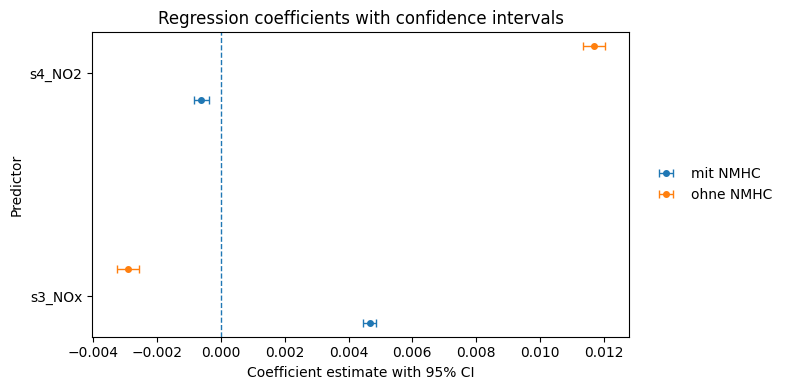

In [35]:
regression.plot_coef_compare([m1, m3], names=["mit NMHC", "ohne NMHC"], filter="NO")
# NOx (und auch NO2) wechseln ganz offensichtlich das Vorzeichen
# Warum? Erklärung siehe oben.
# Wir wollen hier nochmal ins Detail gehen

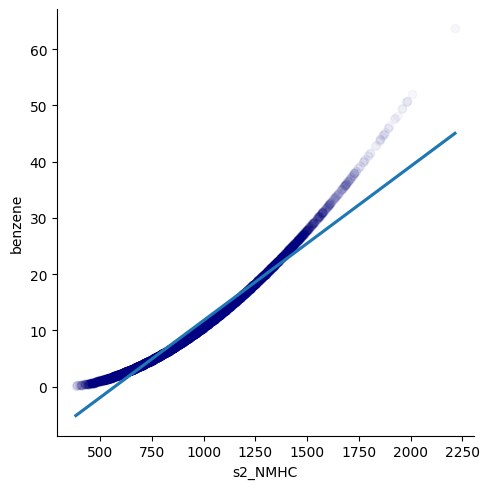

In [36]:
# Schauen wir uns der Reihe nach den paarweisen Zusammenhang als Scatterplot an
# Als erstes: NMHC vs Benzol
sns.lmplot(air, x="s2_NMHC", y="benzene", scatter_kws={ "color": "navy", "alpha": 0.03})

Wir sehen zweierlei: erstens eine eindeutige positive Korrelation, die aber, zweitens, nicht linear ist.
Sieht eher quadratisch aus. Ginge es uns um die Güte des Modell, würden wir nun ein besseres Modell aufsetzen, welches diesen nicht-linearen Zusammenhang besser abbildet. Uns interessiert das hier aber vorerst nicht.

Wir merken uns: steigt NMHC, steigt auch Benzol.

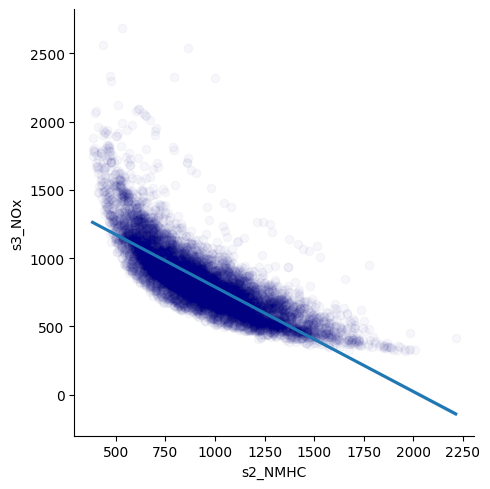

In [37]:
# Zweiter Plot: NMHC vs NOx
sns.lmplot(air, x="s2_NMHC", y="s3_NOx", scatter_kws={ "color": "navy", "alpha": 0.03})

Wir sehen wieder einen nicht-linearen Zusammenhang (ignorieren wir fürs erste), aber vor allem eine negative Korrelation. D.h. je höher NMHC desto niedriger NOx.

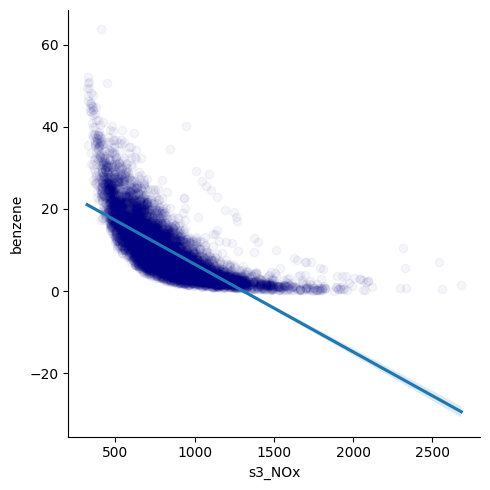

In [38]:
# Dritter Plot: NOx vs. Benzol.
# Also nur die paarweise Betrachtung, ohne Berücksichtigung anderer Variablen
air["NMHC_bins"] = pd.cut(air["s2_NMHC"], bins=10)
sns.lmplot(air, x="s3_NOx", y="benzene", scatter_kws={ "color": "navy", "alpha": 0.04})

# NOx -- wenn wir andere Variable ignorieren -- hat eine negative Korrelation mit Benzol.
# Wie kehrt sich das in ein positives Vorzeichen um, wenn wir NMHC dazu nehmen?

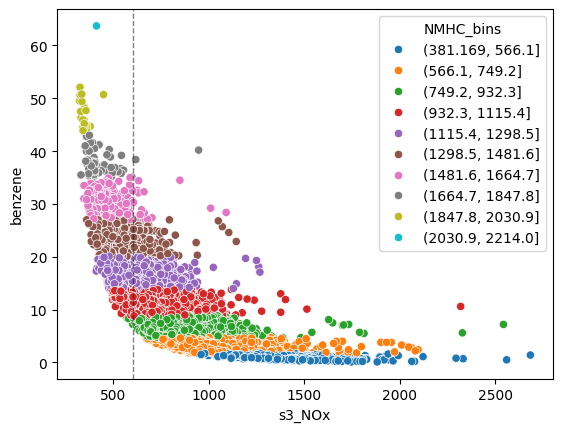

In [39]:
# Einen Hinweis gibt uns dieser Plot, bei dem wir die Punkte in Abhängigkeit
# von 10 NMHC-Gruppen einfärben
air["NMHC_bins"] = pd.cut(air["s2_NMHC"], bins=10)
ax = sns.scatterplot(air, x="s3_NOx", y="benzene", hue="NMHC_bins")
ax.axvline(x=600, color="black", linestyle="--", linewidth=1, alpha=0.5)

Wenn wir z.B. auf den Bereich NOx=600 schauen: hier kann Benzol den Wertebereich von 5..40 annehmen. Ein sehr großes Intervall. Das bedeutet: NOx bestimmt den Benzolwert nur schwach, hat also einen kleinen Effekt. Entlang dieser Linie aber bestimmt NMHC ganz eindeutig die Höhe des Benzolwerts. Je höher NMHC, desto höher das Benzol.

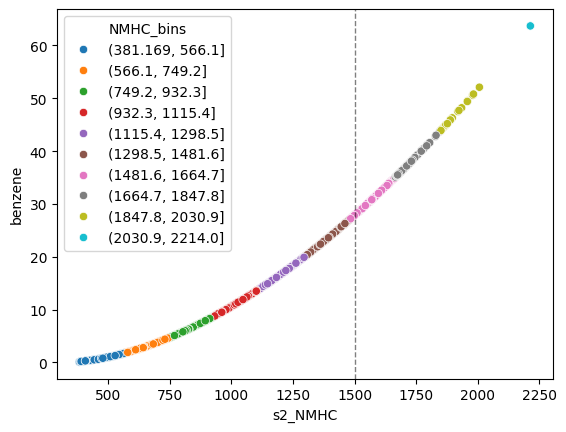

In [40]:
# Umgekehrt ist das nicht der Fall:
air["NOx_bins"] = pd.cut(air["s3_NOx"], bins=10)
ax = sns.scatterplot(air, x="s2_NMHC", y="benzene", hue="NMHC_bins")
ax.axvline(x=1500, color="black", linestyle="--", linewidth=1, alpha=0.5)

Zwar sehen wir auch hier eine fein säuberliche Trennung, allerdings gibt es wenig Spielraum.
Z.B. bei NMHC=1500, gibt variiert Benzol nur von 27.8 bis 28, wie im Teilauschnitt unten zu sehen.
D.h. NOx hat keinen starken Einfluss, es "beugt sich" dem starken Einfluss von NMHC.

(25.0, 30.0)

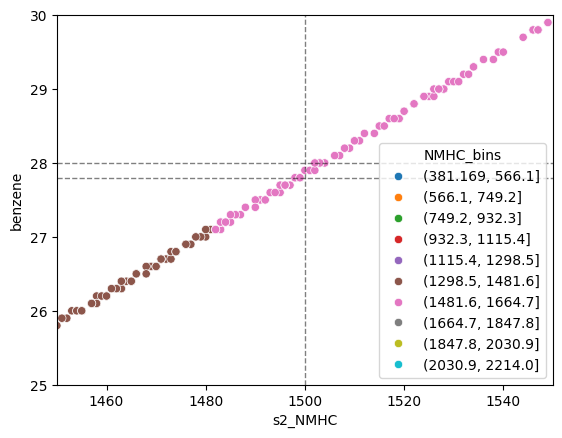

In [41]:
# Zoom: NMHC= 1450..1550
ax = sns.scatterplot(air, x="s2_NMHC", y="benzene", hue="NMHC_bins")
ax.axvline(x=1500, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=28, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=27.8, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlim(1450, 1550)
ax.set_ylim(25, 30)

### Partial Residual Plots

Partial-Residual-Plots zeigen den Zusammenhang zwischen einer einzelnen erklärenden Variable und der Zielvariable, nachdem der Einfluss der anderen Variablen im Regressionsmodell herausgerechnet wurde.

Sie helfen zu prüfen, ob der geschätzte Effekt einer Variable plausibel linear ist oder ob z.B. Krümmungen, Ausreißer oder systematische Muster sichtbar werden. Die Steigung der eingezeichneten Linie entspricht dem Regressionskoeffizienten dieser Variable im vollständigen Modell.

Wichtig: Ein Partial-Residual-Plot zeigt nicht den einfachen bivariaten Zusammenhang, sondern den Zusammenhang **unter Kontrolle der übrigen Modellvariablen**. (Die anderen Variablen werden "herausgerechnet".)


In [42]:
fit1 = regression.fit_ols("s3_NOx ~ s2_NMHC", data=air)
fit2 = regression.fit_ols("benzene ~ s2_NMHC", data=air)

nox_resid = fit1.resid
benz_resid = fit2.resid
df_resid = pd.DataFrame({
    "nox_resid": nox_resid,
    "benz_resid": benz_resid,
    "NMHC_bins": air["NMHC_bins"]
})

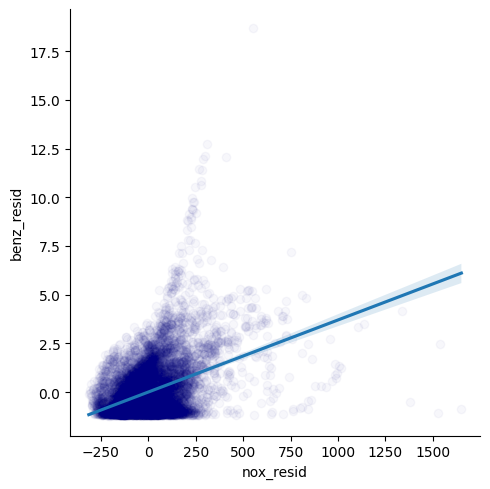

In [43]:
sns.lmplot(data=df_resid, x="nox_resid", y="benz_resid", scatter_kws={ "color": "navy", "alpha": 0.03})

Wie zu sehen gibt es nun auch negative Werte, zum Beispiel beim NOx bis -250. 

Interpretation des Partial-Residual-Plots: bspw. für einen Punkt, der bei `nox_resid=+100` und `benz_resid=+0.5` ist: für den NMHC-Wert, den der Punkt hat, hat dieser mehr NOx (+100) als der NMHC-Wert erwarten ließe und mehr Benzol (+0.5) als erwartet. Der Effekt muss also vom NOx sein -> das ist der Koeffizient von NOx **wenn man NMHC kontrolliert** (=berücksichtigt & dessen Effekt herausrechnet).

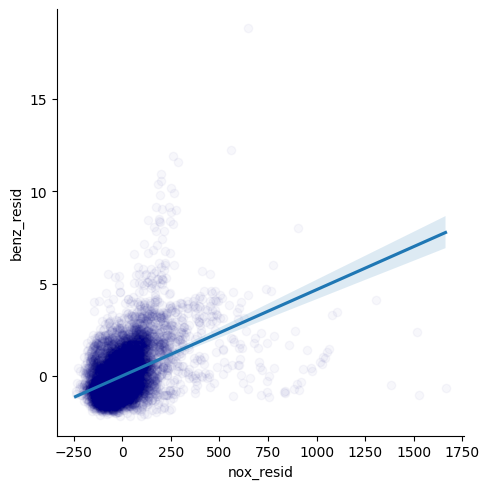

In [44]:
# Mit dem vollen Modell aus m1
# Man setzt wieder zwei Modelle an: eines für NOx, eines für Benzol und 
# lässt jeweils NOx auf der rechten Seite weg
fit3 = regression.fit_ols("s3_NOx ~ T + AH + RH + s1_CO + s2_NMHC + s4_NO2 + s5_O3", data=air)
fit4 = regression.fit_ols("benzene ~ T + AH + RH + s1_CO + s2_NMHC + s4_NO2 + s5_O3", data=air)

nox_resid2 = fit3.resid
benz_resid2 = fit4.resid
df_resid2 = pd.DataFrame({
    "nox_resid": nox_resid2,
    "benz_resid": benz_resid2,
})
sns.lmplot(data=df_resid2, x="nox_resid", y="benz_resid", scatter_kws={ "color": "navy", "alpha": 0.03})

In [45]:
# Die Steigung entspricht genau dem Koeffizienten von NOx aus Modell 1
steigung = regression.fit_ols("benz_resid ~ nox_resid", data=df_resid2).params["nox_resid"]
# Vergleich der beiden
np.round([steigung,
          m1.params['s3_NOx']], 8)

array([0.00466797, 0.00466797])

In Summe ist also weder M1 noch M2 noch M3 die volle Wahrheit, sondern jedes zeigt einen Ausschnitt bzw. Teilaspekt der Wahrheit. Beide der folgenden Aussagen sind wahr. Der Unterschied im Koeffizienten ergibt sich einfach dadurch, dass NOx und NMHC stark korrelieren.

#### Ohne Kohlenwasserstoffe

Wenn uns NMHC nicht bekannt ist, dann können wir sagen (M3):

> NOx hat einen *negativen Einfluss* auf Benzol, wenn wir in unserem Modell für T, AH, RH, CO, NO2 und O3 kontrollieren.

Anders ausgedrückt: Zwei Messpunkte, bei denen *alle anderen Variablen gleich* sind, unterscheiden sich um -0.3 µg/m³ Benzol je 100 ppb NOx. (ppb=parts per billion)

#### Mit Kohlenwasserstoffen

Da uns NMHC nun bekannt ist, können wir sagen (M1):

> NOx hat einen *positiven Einfluss* auf Benzol, wenn wir in unserem Modell für T, AH, RH, CO, NO2, O3 **und NMHC** kontrollieren.

Anders ausgedrückt: Zwei Messpunkte, bei denen *alle anderen Variablen gleich* sind (inkl. NMHC), unterscheiden sich um +0.47 µg/m³ Benzol je 100 ppb NOx. (ppb=parts per billion)

In [46]:
# Die hohe Multikolinearität sieht man auch mit VIF
# (Werte >10 werden als problematisch betrachtet)
# NMHC mit 16 ist im kritischen Bereich -- gepaart mit dem großen Effekt, den NMHC hat,
# sehen wir die Auswirkungen wie oben diskutiert
regression.vif_table(m1, air)

,variable,VIF
0,Intercept,272.718954
1,T,13.844231
2,AH,9.894327
3,RH,7.675966
4,s1_CO,7.996159
5,s2_NMHC,16.074091
6,s3_NOx,4.340365
7,s4_NO2,10.257498
8,s5_O3,8.217338
